### Распознавание числовых данных на фото и систематизация файлов

Целью проекта является упрощение и ускорение процесса ручного переименования фото и систематизации фото в полевом фотоархиве за счёт автоматизации.

Целевая вудитория - члены экспедиции, а также исследователи, занимающиеся камеральной обработкой полевых фотоматериалов.

Основные задачи:  
Распознавание числовых данных в файлах с изображениями.  
Групповое переименование файлов с использованием распознанных данных.  
Формирование отчёта с результатами переименования файлов.  


### Описание данных

Файлы с фотоизображениями, полученные с фотокамеры, сохранены на жестком диске. Объем - 1200 фотографий.

Распознаваемые данные представляют печатные номера, нанесённые на табличку стандартного вида. Номер может иметь от 1 до 4 разрядов и содержать одну латинскую букву (только a, b, c, d и e) в конце. Также на табличке с нумерацией присутствует указатель на север, который должен игнорироваться.


### Ожидаемый эффект от внедрения

Ускорение ручного переименования файлов на 90-95%, сокращение времени, необходимого на первичную систематизацию файлов в фотоархиве на 80%.  
Примерная ожидаемая скорость обработки: 1000 файлов за 20 минут.

### Этапы проекста

С учетом исходной инфомации предполагаемыми этапами проекта будет следующие:
1. Разметка данных.
2. Обучение модели для детекции объектов.
3. Распознавание текста на найденных объектах.
4. Переименование файлов в соответствии с паспознанный текстом.

### Установщики

In [1]:
#!pip install ultralytics

In [2]:
#!pip install roboflow                

In [3]:
#pip install ultralytics roboflow jupyter

In [4]:
#pip install easyocr

In [5]:
#!pip uninstall torch torchvision torchaudio -y

In [6]:
#!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

In [7]:
#!conda install pytorch torchvision torchaudio pytorch-cuda=12.1 -c pytorch -c nvidia -y

In [8]:
#pip install python-doctr[torch]

### Импорты

In [9]:
%matplotlib inline

In [10]:
import torch
print(f"CUDA доступна: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Видеокарта: {torch.cuda.get_device_name(0)}")

CUDA доступна: True
Видеокарта: NVIDIA GeForce GTX 970


In [11]:
import numpy
print(numpy.__version__)
import ultralytics
print(ultralytics.__version__)

2.2.6
8.4.33


In [12]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.5.1+cu121
True


In [13]:
from ultralytics import YOLO

In [14]:
from roboflow import Roboflow

In [15]:
import matplotlib.pyplot as plt

In [16]:
import cv2

In [17]:
import os
import time
from IPython.display import clear_output

In [18]:
import easyocr

In [19]:
import numpy as np

In [20]:
import csv

In [21]:
from doctr.models import ocr_predictor

In [22]:
from doctr.models import recognition_predictor

In [23]:
import shutil
import random
import string

In [24]:
import pandas as pd
import re

### Загрузка с roboflow

Первый этап, разметка, осуществлялся с помощью robboflow.

In [25]:
#from roboflow import Roboflow
rf = Roboflow(api_key="ODNygUs9xqfi2bwSAnWk")
project = rf.workspace("s-workspace-gkrui").project("myobjectdetection400")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


In [71]:
model = YOLO("yolo11n.pt") 

### Тренировка модели

Второй этап, обучение модели для детекции объектов, осуществлялся с помощью библиотеки yolo.  
Была использована yolo8, как не самый новый, но проверенный надежный вариант.

In [72]:
results = model.train(
    data=f"{dataset.location}/data.yaml", # Путь к файлу с описанием данных
    epochs=50,         # Сколько раз нейросеть «просмотрит» все фото
    imgsz=640,         # Размер изображения (стандарт для YOLO)
    plots=True,        # Рисовать графики точности
    device=0#'cpu'          # Использовать видеокарту (если есть). Если нет — пишите 'cpu'
)

New https://pypi.org/project/ultralytics/8.4.35 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.33  Python-3.10.20 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 970, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\pogar\jupyter projects\roboflow\MyObjectDetection400-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.9

### Загрузка обученной модели

In [26]:
#model_path = 'runs/detect/train9/weights/best.pt' 
model_path = 'runs/detect/train11/weights/best.pt' 

In [27]:
model = YOLO(model_path)

### Тест детекции по одной картинке

#### разные файлы для проверки

In [28]:
#my_path = "C:/Users/user/jupyter_projects/roboflow/MyObjectDetention-3/test/images/"
my_path = "C:/Users/pogar/jupyter projects/roboflow/MyObjectDetention-3/test/images/"

In [35]:
jpeg_file = "MDZ087-_3_JPG.rf.aef613803ec2b858db135febb18c481a.jpg"

In [23]:
jpeg_file = "MDZ087-_9_JPG.rf.5d3701f7d847c579ad6c6c8bc569dc32.jpg"

In [24]:
jpeg_file = "MDZ087-_3_JPG.rf.aef613803ec2b858db135febb18c481a.jpg"

In [25]:
jpeg_file= "MDZ087 _3.jpg"

In [26]:
jpeg_file = "MDZ086.jpg"

In [31]:
jpeg_file = "SDB2012.jpg"

In [28]:
jpeg_file = "TUL015.jpg"

In [32]:
results = model.predict(source=my_path + jpeg_file, conf=0.25)


image 1/1 C:\Users\pogar\jupyter projects\roboflow\MyObjectDetention-3\test\images\SDB2012.jpg: 640x448 1 MyObjectDetection400, 42.9ms
Speed: 9.9ms preprocess, 42.9ms inference, 21.3ms postprocess per image at shape (1, 3, 640, 448)


Найдено объектов: 1


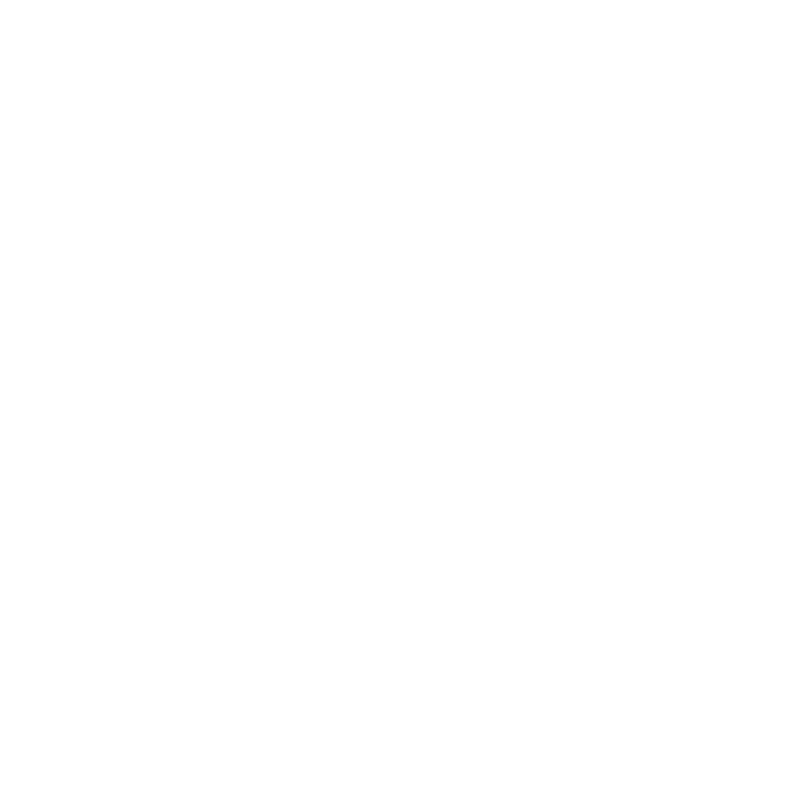

In [33]:
print(f"Найдено объектов: {len(results[0].boxes)}")
for r in results:
    # Переводим изображение из формата BGR (OpenCV) в RGB (для корректных цветов в matplotlib)
    im_rgb = cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 10))
    #plt.imshow(im_rgb)
    plt.axis('off')
    plt.show()

### Easyocr

Для распознавания текста начальный выбор пал на easyocr.

In [34]:
reader = easyocr.Reader(['en']) # Выберите нужные языки

In [35]:
img_path = my_path + jpeg_file #'test_image.jpg'

In [36]:
img = cv2.imread(img_path)

### Тест распознования одной картинки, самый первый вариант


0: 640x640 1 MyObjectDetection400, 24.0ms
Speed: 28.5ms preprocess, 24.0ms inference, 8.7ms postprocess per image at shape (1, 3, 640, 640)
Обнаружен объект в координатах [343, 249, 377, 262]
Текст на объекте: 8 7


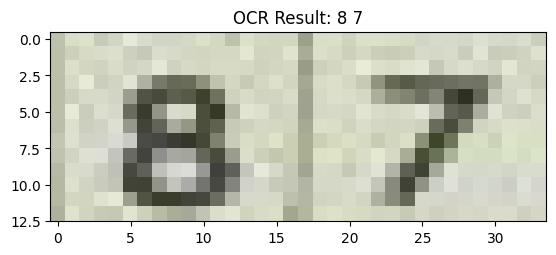

In [38]:
results = model(img)

for r in results:
    for box in r.boxes:
        # Получаем координаты рамки (целые числа)
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        
        # Обрезаем изображение по границам объекта (Кроп)
        crop_img = img[y1:y2, x1:x2]
        
        # 4. Распознавание текста на кропе
        # paragraph=True помогает, если текст в несколько строк
        ocr_results = reader.readtext(crop_img, detail=0) 
        
        # Вывод результата
        text = " ".join(ocr_results)
        print(f"Обнаружен объект в координатах [{x1}, {y1}, {x2}, {y2}]")
        print(f"Текст на объекте: {text}")
        
        # Визуализация для контроля
        plt.imshow(cv2.cvtColor(crop_img, cv2.COLOR_BGR2RGB))
        plt.title(f"OCR Result: {text}")
        plt.show()

### reco_model (docTR)

После многих попыток довести до приемлемого результата easyocr была добавлена другая библиотека docTR.  
В дальнейшем использовались оба варианта.

In [40]:
reco_model = recognition_predictor(arch='crnn_vgg16_bn', pretrained=True)

### Тест распознования, итоговый вариант

#### пути my_path

Пути использовались для различных проверок

In [41]:
#my_path = "F:/project_04_2026/test"
my_path = "D:/project_04_2026/test"

In [42]:
my_path = "D:/project_04_2026/test5"

In [41]:
my_path = "D:/project_04_2026/test8"

In [49]:
#my_path = "F:/project_04_2026/data"
my_path = "D:/project_04_2026/data"


Файл: MDZ087 _7.JPG
Найдено объектов: 2


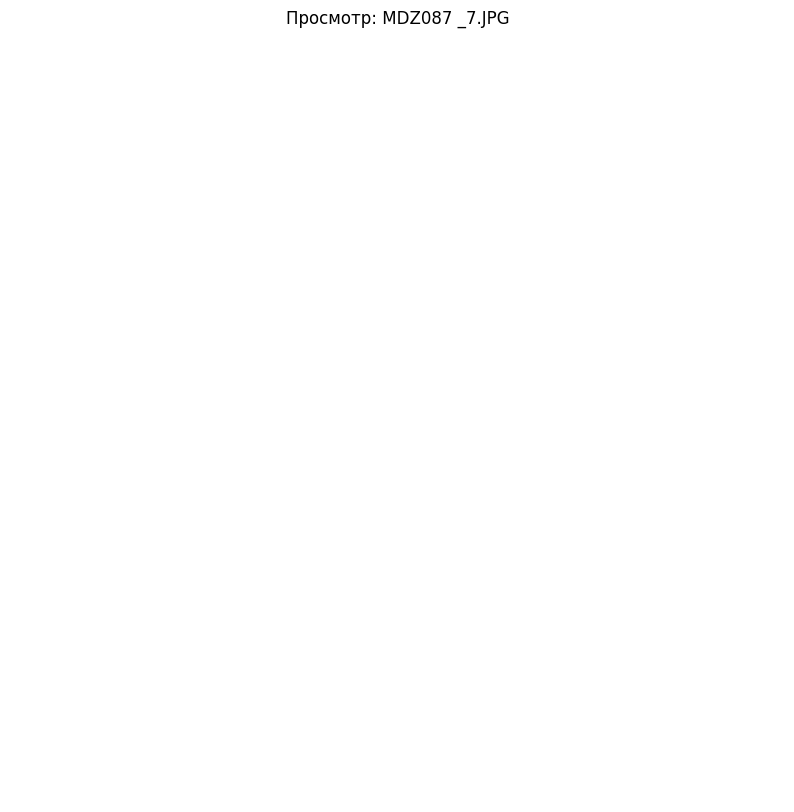

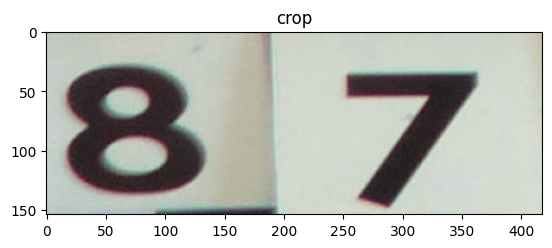

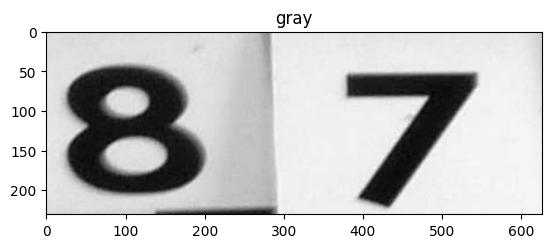

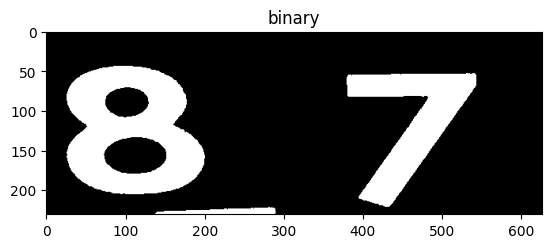

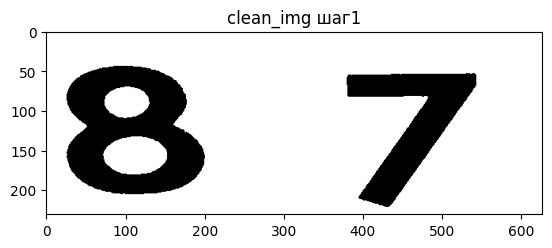

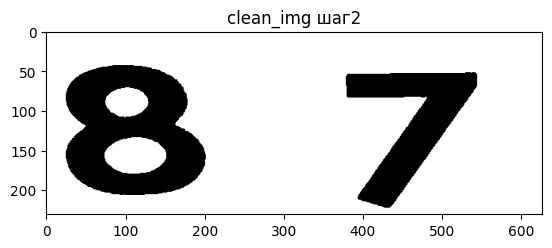


Распознано easyocr: 87


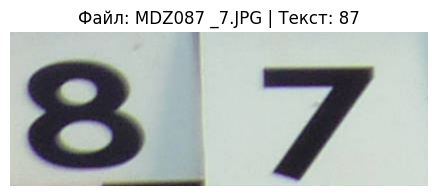

DocTR нашел: 87 | Уверенность: 1.00


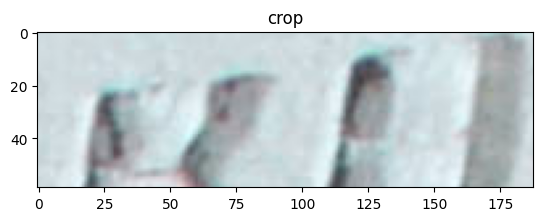

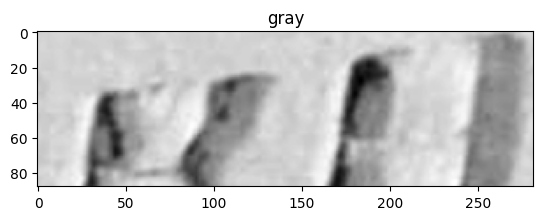

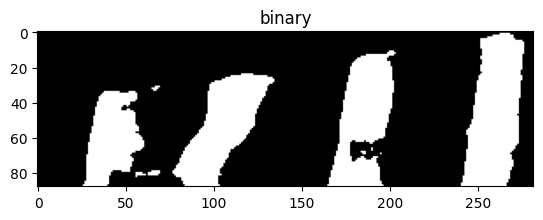

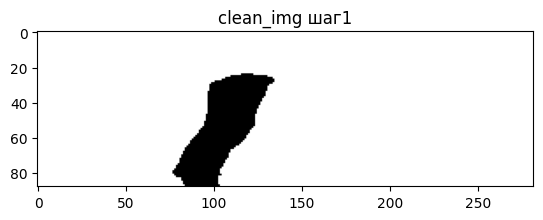

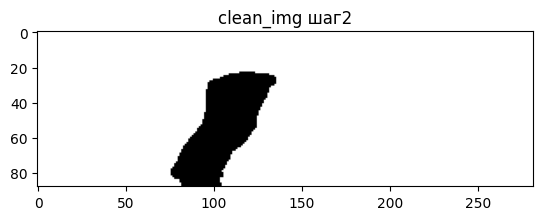

Текст не найден на этом кропе.
DocTR нашел: e | Уверенность: 0.37


In [ ]:
files = [f for f in os.listdir(my_path) if f.lower().endswith(('.jpg', '.jpeg'))]

for file_name in files:
    img_path = os.path.join(my_path, file_name)
    img = cv2.imread(img_path)
    if img is None: continue

    results = model(img, verbose=False, conf=0.5)
    
    # Очищаем экран для нового фото
    clear_output(wait=True)

    # Инициализация для EasyOCR
    best_easy_text = ""
    max_easy_conf = -1.0


    #################### yolo 
    full_path = os.path.join(my_path, file_name)
    print(f"Файл: {file_name}")
    print(f"Найдено объектов: {len(results[0].boxes)}")
    for r in results:
        im_rgb = cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 10))
        #plt.imshow(im_rgb)
        plt.title(f"Просмотр: {file_name}")
        plt.axis('off')
        plt.show()
    #################### yolo 


    
    for r in results:
        for box in r.boxes:
        
            # Координаты и кроп
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            w, h = x2 - x1, y2 - y1
            pad_w, pad_h = int(w * 0.02), int(h * 0.02)
            
            crop = img[max(0, y1+pad_h):min(img.shape[0], y2-pad_h), 
                       max(0, x1+pad_w):min(img.shape[1], x2-pad_w)]

            # Подготовка (увеличение)
            crop_resized = cv2.resize(crop, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_CUBIC)


            # --- ПОДГОТОВКА ДЛЯ OCR ---
            # Переводим в ч/б (градации серого)
            # бинаризация
            gray = cv2.cvtColor(crop_resized, cv2.COLOR_BGR2GRAY)


            
            # ЖЕСТКИЙ ПОРОГ: оставляем только самое черное 
            # Всё, что светлее 80, станет белым.
            #_, binary = cv2.threshold(gray, 80, 255, cv2.THRESH_BINARY_INV) # Инвертируем: буквы белые на черном для поиска контуров
            _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)


            # Визуализация для контроля (помогает настроить порог)
            plt.imshow(crop, cmap='gray')
            plt.title("crop")
            plt.show()


            # Визуализация для контроля (помогает настроить порог)
            plt.imshow(gray, cmap='gray')
            plt.title("gray")
            plt.show()



            # Визуализация для контроля (помогает настроить порог)
            plt.imshow(binary, cmap='gray')
            plt.title("binary")
            plt.show()

            


            # ФИЛЬТРАЦИЯ ПО РАЗМЕРУ: ищем все объекты (буквы)
            # Ищем контуры с иерархией (CCOMP позволяет видеть "дырки")
            contours, hierarchy = cv2.findContours(binary, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)

            mask = np.zeros_like(binary)
            min_height = crop_resized.shape[0] * 0.4 # Игнорируем всё, что меньше 40% высоты картинки

            # Берем 25% от ВЕРТИКАЛЬНОГО размера картинки
            limit_h = int(crop_resized.shape[0] * 0.25) 

            
            if hierarchy is not None:
                # hierarchy[0] содержит данные [Next, Previous, First_Child, Parent]
                hierarchy = hierarchy[0]
                for i, cnt in enumerate(contours):
                    # Проверяем, является ли контур "внешним" (у него нет родителя)
                    if hierarchy[i][3] == -1: 
                        x, y, w, h = cv2.boundingRect(cnt)

                        aspect_ratio = w / float(h) # Соотношение ширины к высоте

                        
                        # Слишком широкие объекты (линии подчеркивания)
                        # Если ширина объекта больше 70% от всей ширины картинки - это не цифра
                        is_too_wide = w > (crop_resized.shape[1] * 0.7)

                                                
                        # Слишком узкие объекты (линии подчеркивания)
                        is_too_shallow = w < (crop_resized.shape[1] * 0.2)

                        # Слишком высокие объекты (края табличек)
                        # Если высота почти на весь кроп (90%+) - скорее всего, это край
                        is_too_high = h > (crop_resized.shape[0] * 0.9)

                        # 3. Уточняем пропорции для цифр
                        # Цифра обычно не бывает в 5 раз выше своей ширины (палка) 
                        # и не бывает в 5 раз шире своей высоты (линия)
                        is_normal_shape = (0.2 < aspect_ratio < 1.5)

                        # УСЛОВИЯ ФИЛЬТРАЦИИ:
                        # 1. Высота больше 25% от картинки (уже было)
                        # 2. Соотношение сторон больше 0.2 (цифры шире, чем тонкие палки)
                        # 3. Абсолютная ширина больше 10-15 пикселей (отсекаем тонкие линии)

                        if h > limit_h and not is_too_wide and not is_too_high and is_normal_shape and not is_too_shallow:
                            # Рисуем сам внешний контур (белым)
                            cv2.drawContours(mask, contours, i, 255, -1)
                            

                            child = hierarchy[i][2]
                            while child != -1:
                                cv2.drawContours(mask, contours, child, 0, -1)
                                child = hierarchy[child][0]

            # Возвращаем обратно: черные буквы на белом фоне (только крупные)
            clean_img = cv2.bitwise_not(mask)

            # Визуализация для контроля (помогает настроить порог)
            plt.imshow(clean_img, cmap='gray')
            plt.title("clean_img шаг1")
            plt.show()

            # Немного расширяем черные линии (1-2 пикселя), чтобы символы были монолитными
            kernel = np.ones((3, 3), np.uint8)
            # Так как у нас черные буквы на белом, используем erosion для утолщения черного
            clean_img = cv2.erode(clean_img, kernel, iterations=1) 

            # Визуализация для контроля (помогает настроить порог)
            plt.imshow(clean_img, cmap='gray')
            plt.title("clean_img шаг2")
            plt.show()


            # OCR с агрессивной склейкой пробелов
            easy_results = reader.readtext(
                #crop,
                #crop_resized, 
                #thresh, 
                clean_img,
                allowlist='0123456789abcde', 
                rotation_info=[0, 10, -10],
                paragraph=True, 
                x_ths=5.0,  
                y_ths=2.0, 
                decoder='greedy', # Меньше галлюцинаций
                add_margin=0.1, 
                detail=1
            )

            #для easyocr берем только вариант с максимальной уверенностью по детекции
            if easy_results:
                curr_easy_text = easy_results[0][1] 

                curr_yolo_conf = float(box.conf[0])

                if curr_yolo_conf > max_easy_conf:
                    max_easy_conf = curr_yolo_conf
                    best_easy_text = curr_easy_text.replace(" ", "").strip()

            # Вывод результата
            if not easy_results:
                print("Текст не найден на этом кропе.")
            else:
                print()
                #print(f"Распознано: {best_easy_text}")
            
            for (bbox, text) in easy_results:
                clean_text = text.replace(" ", "").strip()
                print(f"Распознано easyocr: {clean_text}")
                
                # Показываем что именно видел OCR
                plt.figure(figsize=(6, 2))
                plt.imshow(cv2.cvtColor(crop_resized, cv2.COLOR_BGR2RGB))
                plt.title(f"Файл: {file_name} | Текст: {clean_text}")
                plt.axis('off')
                plt.show()


            
            #начало docTR
            
            # Подготовка: добавляем поля и переводим в RGB
            # Поля (padding) нужны, чтобы буквы не прижимались к краям
            temp_crop = cv2.copyMakeBorder(crop, 15, 15, 15, 15, cv2.BORDER_REPLICATE)
            img_rgb = cv2.cvtColor(temp_crop, cv2.COLOR_BGR2RGB)
            
            # Прямое распознавание (без поиска блоков)
            out = reco_model([img_rgb])
            
            # 3. Извлечение текста (out возвращает список кортежей [('текст', уверенность)])
            raw_text, confidence = out[0]
            
            final_text = ""
            if confidence >= 0.3:  # Для "диких" условий 0.3 - это уже зацепка
                final_text = "".join([c for c in raw_text.lower() if c in '0123456789abcde'])
                print(f"DocTR нашел: {final_text} | Уверенность: {confidence:.2f}")
            else:
                print(f"DocTR не уверен: {raw_text} ({confidence:.2f})")



    input("Нажмите Enter для перехода к следующему файлу...")


### Копирование случайного количество файлов в папку

Для тестирования были сделаны несколько дополнительных этапов:
1. Копирование случайного количество файлов в папку.
2. Получение списка файлов в папке.
3. Переименование файлов папки в случайные названия.

In [69]:
# Пути к папкам
source_folder = "d:/project_04_2026/data"
destination_folder = "d:/project_04_2026/selection"  # папка для скопированных файлов

# Количество файлов для копирования
num_files_to_copy = 400

# Создаём целевую папку, если её нет
os.makedirs(destination_folder, exist_ok=True)

# Получаем список всех файлов в исходной папке (исключаем подпапки)
files = [f for f in os.listdir(source_folder)
         if os.path.isfile(os.path.join(source_folder, f))]

# Проверяем, достаточно ли файлов в папке
if len(files) < num_files_to_copy:
    print(f"Внимание: в папке только {len(files)} файлов. Будут скопированы все.")
    num_files_to_copy = len(files)

# Выбираем 350 случайных файлов
selected_files = random.sample(files, num_files_to_copy)

# Копируем выбранные файлы
copied_count = 0
for file_name in selected_files:
    source_path = os.path.join(source_folder, file_name)
    destination_path = os.path.join(destination_folder, file_name)

    try:
        shutil.copy2(source_path, destination_path)  # copy2 сохраняет метаданные файла
        copied_count += 1
    except Exception as e:
        print(f"Ошибка при копировании файла {file_name}: {e}")

print(f"Успешно скопировано {copied_count} файлов в папку: {destination_folder}")


Успешно скопировано 400 файлов в папку: d:/project_04_2026/selection


### Список файлов в папке

In [60]:
folder_path = "D:/project_04_2026/data" 

# Получаем список всех файлов (и папок) в директории
files = os.listdir(folder_path)

# Сохраняем в CSV
with open('files_list.csv', 'w', newline='', encoding='utf-8') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['Имя файла'])  # заголовок
    for file_name in files:
        writer.writerow([file_name])

print("Список файлов сохранён в files_list.csv")

Список файлов сохранён в files_list.csv


### Переименование для тестирования

In [46]:
# Укажи путь к своей папке
#folder_path = 'путь/к/твоей/папке'
folder_path = 'D:/project_04_2026/data_random'

# Собираем список всех jpeg/jpg файлов
files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg'))]

for filename in files:
    # Генерируем 8 случайных символов (буквы + цифры)
    random_name = ''.join(random.choices(string.ascii_letters + string.digits, k=8))
    
    # Сохраняем расширение исходного файла
    extension = os.path.splitext(filename)[1]
    new_name = random_name + extension
    
    # Полные пути
    old_file = os.path.join(folder_path, filename)
    new_file = os.path.join(folder_path, new_name)
    
    # Переименовываем
    os.rename(old_file, new_file)

print(f"Готово! Переименовано файлов: {len(files)}")

Готово! Переименовано файлов: 1200


### Проверка с записью в CSV

После зрительной проверки отдельных списков была осуществлена проверка всех имеющихся файлов с записью результата в csv.

In [60]:
start_time = time.time()
csvfile = open('results_ocr.csv', 'w', newline='', encoding='utf-8')
writer = csv.writer(csvfile)
#writer.writerow(['File Name', 'EasyOCR Text', 'DocTR Text']) # Заголовки колонок
writer.writerow(['File Name', 'EasyOCR Text', 'DocTR Main', 'Conf Main','DocTR Others'])
counter = 1

files = [f for f in os.listdir(my_path) if f.lower().endswith(('.jpg', '.jpeg'))]

for file_name in files:
    img_path = os.path.join(my_path, file_name)
    img = cv2.imread(img_path)
    if img is None: continue

    results = model(img, verbose=False)
    
    # Очищаем экран для нового фото
    clear_output(wait=True)

    best_easy_text = ""
    max_easy_conf = -1.0



    #print(f"--- Файл: {file_name} ---")
    easy_text = ''
    doctr_text = ''

    best_doctr_text = ""
    max_ocr_conf = -1.0

    best_main_text = ""
    best_main_conf = -1.0
    all_other_findings = []

    best_easy_text = ""

    for r in results:

        for box in r.boxes:

            
        
            # Координаты и кроп
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            w, h = x2 - x1, y2 - y1
            pad_w, pad_h = int(w * 0.02), int(h * 0.02)
            
            crop = img[max(0, y1+pad_h):min(img.shape[0], y2-pad_h), 
                       max(0, x1+pad_w):min(img.shape[1], x2-pad_w)]

            # Подготовка (увеличение)
            crop_resized = cv2.resize(crop, None, fx=1.0, fy=1.0, interpolation=cv2.INTER_CUBIC)


            
            # ПОДГОТОВКА ДЛЯ OCR ---
            # Переводим в ч/б (градации серого)
            # бинаризация
            gray = cv2.cvtColor(crop_resized, cv2.COLOR_BGR2GRAY)
    

            # ЖЕСТКИЙ ПОРОГ: оставляем только самое черное (регулируйте 70-100)
            # Всё, что светлее 80, станет белым.
            #_, binary = cv2.threshold(gray, 80, 255, cv2.THRESH_BINARY_INV) # Инвертируем: буквы белые на черном для поиска контуров
            _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

            
            # ФИЛЬТРАЦИЯ ПО РАЗМЕРУ: ищем все объекты (буквы)
            #contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            # Ищем контуры с иерархией (CCOMP позволяет видеть "дырки")
            contours, hierarchy = cv2.findContours(binary, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)

            mask = np.zeros_like(binary)
            min_height = crop_resized.shape[0] * 0.4 # Игнорируем всё, что меньше 40% высоты картинки


            # Берем 25% от ВЕРТИКАЛЬНОГО размера картинки
            limit_h = int(crop_resized.shape[0] * 0.25) 


            if hierarchy is not None:
                # hierarchy[0] содержит данные [Next, Previous, First_Child, Parent]
                hierarchy = hierarchy[0]
                for i, cnt in enumerate(contours):
                    # Проверяем, является ли контур "внешним" (у него нет родителя)
                    #if hierarchy[0][i][3] == -1:
                    if hierarchy[i][3] == -1: 
                        x, y, w, h = cv2.boundingRect(cnt)

                        aspect_ratio = w / float(h) # Соотношение ширины к высоте

                        

                        # Слишком широкие объекты (линии подчеркивания)
                        # Если ширина объекта больше 70% от всей ширины картинки - это не цифра
                        is_too_wide = w > (crop_resized.shape[1] * 0.7)
                        
                        # Слишком высокие объекты (края табличек)
                        # Если высота почти на весь кроп (90%+) - скорее всего, это край
                        is_too_high = h > (crop_resized.shape[0] * 0.9)
                        
                        # Уточняем пропорции для цифр
                        # Цифра обычно не бывает в 5 раз выше своей ширины (палка) 
                        # и не бывает в 5 раз шире своей высоты (линия)
                        is_normal_shape = (0.2 < aspect_ratio < 1.5)

                        
                        # УСЛОВИЯ ФИЛЬТРАЦИИ:
                        # 1. Высота больше 25% от картинки (уже было)
                        # 2. Соотношение сторон больше 0.2 (цифры шире, чем тонкие палки)
                        # 3. Абсолютная ширина больше 10-15 пикселей (отсекаем тонкие линии)
                        
                        if h > limit_h and not is_too_wide and not is_too_high and is_normal_shape:
                            # Рисуем сам внешний контур (белым)
                            cv2.drawContours(mask, contours, i, 255, -1)

                            child = hierarchy[i][2]
                            while child != -1:
                                cv2.drawContours(mask, contours, child, 0, -1)
                                child = hierarchy[child][0]

            # Возвращаем обратно: черные буквы на белом фоне (только крупные)
            clean_img = cv2.bitwise_not(mask)

            # Немного расширяем черные линии (1-2 пикселя), чтобы символы были монолитными
            kernel = np.ones((3, 3), np.uint8)
            # Так как у нас черные буквы на белом, используем erosion для утолщения черного
            clean_img = cv2.erode(clean_img, kernel, iterations=1) 

            

            
            
            # OCR с агрессивной склейкой пробелов
            easy_results = reader.readtext(
                #crop_resized, 
                #thresh, 
                clean_img,
                allowlist='0123456789abcde', 
                #rotation_info=[90, 270],
                rotation_info=[0, 10, -10],
                paragraph=True, 
                x_ths=5.0,  # Еще больше увеличили порог для склейки №4.0
                y_ths=2.0, 
                decoder='greedy', # Меньше галлюцинаций
                add_margin=0.1, 
                detail=1
            )
            #print(easy_results)

            if easy_results:
                # Если EasyOCR нашел несколько строк в одном кропе, берем самую уверенную
                #current_easy_res = sorted(ocr_data, key=lambda x: x[2], reverse=True)[0]
                #curr_easy_text, curr_easy_conf = current_easy_res[1], current_easy_res[2]
                curr_easy_text = easy_results[0][1] 
                
                # Сравниваем с лучшим результатом для всего ФАЙЛА
                #if curr_easy_conf > max_easy_conf:
                #    max_easy_conf = curr_easy_conf
                #    best_easy_text = curr_easy_text.replace(" ", "").strip()

                curr_yolo_conf = float(box.conf[0])
                #print(curr_yolo_conf)

                if curr_yolo_conf > max_easy_conf:
                    max_easy_conf = curr_yolo_conf
                    best_easy_text = curr_easy_text.replace(" ", "").strip()
            

            

            for (bbox, text) in easy_results:
                clean_text = text.replace(" ", "").strip()
                #print(f"Распознано: {clean_text}")
                


            # Подготовка: добавляем поля и переводим в RGB
            # Поля (padding) нужны, чтобы буквы не прижимались к краям
            temp_crop = cv2.copyMakeBorder(crop, 15, 15, 15, 15, cv2.BORDER_REPLICATE)
            img_rgb = cv2.cvtColor(temp_crop, cv2.COLOR_BGR2RGB)
            
            # Прямое распознавание (без поиска блоков)
            out = reco_model([img_rgb])
            if not out: continue

            # Сортируем все найденные слова по убыванию уверенности
            # Теперь out[0] — это всегда самый надежный результат
            sorted_out = sorted(out, key=lambda x: x[1], reverse=True)

            current_text, current_conf = sorted_out[0]

            if current_conf > max_ocr_conf:
                max_ocr_conf = current_conf
                # Чистим текст
                best_doctr_text = "".join([c for c in current_text.lower() if c in '0123456789abcde'])
                
                # Добавляем инфо о других словах в ЭТОМ ЖЕ боксе, если они есть
                others = [word for word, conf in sorted_out[1:] if conf > 0.1]
                if others:
                    best_doctr_text += f" (еще: {' '.join(others)})"

            for raw_text, conf in out:
                # 1. Фильтруем текст
                clean_t = "".join([c for c in raw_text.lower() if c in '0123456789abcde'])
                if not clean_t: continue

                # 2. Если это самый уверенный результат за всё время обработки ФАЙЛА
                if conf > best_main_conf:
                    # Если старый "чемпион" существовал, отправляем его в список "других"
                    if best_main_text:
                        all_other_findings.append(f"{best_main_text}({best_main_conf:.2f})")
                    
                    # Назначаем нового чемпиона
                    best_main_conf = conf
                    best_main_text = clean_t
                else:
                    # 3. Все остальные находки просто копим в список
                    all_other_findings.append(f"{clean_t}({conf:.2f})")
                        


    main_column = best_main_text
    conf_column = best_main_conf

    others_column = ""
    if all_other_findings:
        unique_others = list(set(all_other_findings))
        others_column = ", ".join(unique_others) # Просто перечисляем через запятую

    # Формируем итоговую строку для колонки DocTR
    doctr_final_string = best_main_text
    if all_other_findings:
        # Убираем дубликаты, если вдруг нашли одно и то же в разных рамках
        unique_others = list(set(all_other_findings))
        doctr_final_string += f", [ДРУГОЕ: {', '.join(unique_others)}]"

    writer.writerow([file_name, best_easy_text, main_column, best_main_conf, others_column])
    print(f"{counter}. {file_name} | Easy: {best_easy_text} | Main: {main_column} | conf:{conf_column:.3f} | Others: {others_column}")
    counter += 1
            

    # Пауза для контроля (нажмите Enter для следующего фото)
    #input("Нажмите Enter для перехода к следующему файлу...")


print("Все фото проверены!")

csvfile.close()
end_time = time.time()
elapsed_time = end_time - start_time

print(f"Цикл выполнен за {elapsed_time:.4f} секунд")

1200. TUL920_1.JPG | Easy:  | Main:  | conf:-1.000 | Others: 
Все фото проверены!
Цикл выполнен за 849.2937 секунд


Проверка двумя способами с записью в csv заняла меньше 15 минут.  
Это не переименование, но уже понятно, что скорость обработки приемлемая.

### Расчет accuracy

In [61]:
#Читаем созданный файл
df = pd.read_csv('results_ocr.csv')

def extract_number(filename):
    # Ищем: 3 буквы (за начало), затем цифры (наша цель), 
    # затем пробел, подчеркивание или точку (конец числа)
    match = re.search(r'^[a-zA-Z]{3}(\d+)', filename)
    if match:
        return match.group(1)
    return None

# Создаем новый столбец с числом из имени
# Мы вставляем его вторым (index 1), чтобы он был рядом с именем файла
df.insert(1, 'File_Number', df['File Name'].apply(extract_number))

def clean_file_number(val):
    if val is None:
        return None
    
    # Преобразуем в строку и убираем нули только слева
    cleaned = str(val).lstrip('0')
    
    # Если строка состояла только из нулей (например, "000"), 
    # lstrip удалит всё. В этом случае вернем "0"
    return cleaned if cleaned else "0"

# Применяем к столбцу
df['File_Number'] = df['File_Number'].apply(clean_file_number)

print(df.head())

        File Name File_Number EasyOCR Text DocTR Main  Conf Main DocTR Others
0      MDZ086.JPG          86           86         86   0.998501          NaN
1    MDZ086_1.JPG          86           86         86   0.980945          NaN
2    MDZ086_2.JPG          86           86         86   0.986121          NaN
3   MDZ087 _1.JPG          87            8         87   0.999834          NaN
4  MDZ087 _10.JPG          87           87         87   0.976791          NaN


In [62]:
# 1. Подготовка: приводим всё к строкам, нижнему регистру и убираем пробелы
target = df['File_Number'].astype(str).str.lower().str.strip()
easy_res = df['EasyOCR Text'].astype(str).str.lower().str.strip()
doctr_res = df['DocTR Main'].astype(str).str.lower().str.strip()

# 2. Создаем столбцы совпадений (True/False)
df['Easy_Correct'] = (easy_res == target)
df['DocTR_Correct'] = (doctr_res == target)

# 3. Считаем процент точности
easy_accuracy = df['Easy_Correct'].mean() * 100
doctr_accuracy = df['DocTR_Correct'].mean() * 100

print(f"Точность EasyOCR: {easy_accuracy:.2f}%")
print(f"Точность DocTR: {doctr_accuracy:.2f}%")


Точность EasyOCR: 63.92%
Точность DocTR: 86.25%


Accuracy easyocr невысока. 
Но Accuracy DocTR на приемлемой уровне.

### Переименование и перенос файлов

In [103]:
prefix = "TUL"
output_dir = "D:/project_04_2026/for_rename"          # Папка для уверенных результатов
review_dir = "D:/project_04_2026/manual_review" 
min_conf_limit = 0.9

In [93]:
def get_unique_name(target_name, folder1, folder2):
    #"""Проверяет уникальность имени сразу в двух папках"""
    base, ext = os.path.splitext(target_name)
    final_name = target_name
    counter = 2
    
    # Пока файл с таким именем есть ХОТЯ БЫ в одной из папок
    while os.path.exists(os.path.join(folder1, final_name)) or \
          os.path.exists(os.path.join(folder2, final_name)):
        final_name = f"{base}_{counter}{ext}"
        counter += 1
        
    return final_name

In [102]:
start_time = time.time()
csvfile = open('renaming.csv', 'w', newline='', encoding='utf-8')
writer = csv.writer(csvfile)
writer.writerow(['File Name', 'New Name', 'Folder', 'DocTR Main', 'Conf Main','DocTR Others'])
counter = 1

files = [f for f in os.listdir(output_dir) if f.lower().endswith(('.jpg', '.jpeg'))]

for file_name in files:
    img_path = os.path.join(output_dir, file_name)
    img = cv2.imread(img_path)
    if img is None: continue

    results = model(img, verbose=False)

    clear_output(wait=True)

    doctr_text = ''
    best_doctr_text = ""
    max_ocr_conf = -1.0

    best_main_text = ""
    best_main_conf = -1.0
    all_other_findings = []

    for r in results:

        for box in r.boxes:

            # Координаты и кроп
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            w, h = x2 - x1, y2 - y1
            pad_w, pad_h = int(w * 0.02), int(h * 0.02)
            
            crop = img[max(0, y1+pad_h):min(img.shape[0], y2-pad_h), 
                       max(0, x1+pad_w):min(img.shape[1], x2-pad_w)]

            # Подготовка: добавляем поля и переводим в RGB
            # Поля (padding) нужны, чтобы буквы не прижимались к краям
            temp_crop = cv2.copyMakeBorder(crop, 15, 15, 15, 15, cv2.BORDER_REPLICATE)
            img_rgb = cv2.cvtColor(temp_crop, cv2.COLOR_BGR2RGB)
            
            # Прямое распознавание (без поиска блоков)
            out = reco_model([img_rgb])
            if not out: continue

            # Сортируем все найденные слова по убыванию уверенности
            # Теперь out[0] — это всегда самый надежный результат
            sorted_out = sorted(out, key=lambda x: x[1], reverse=True)

            current_text, current_conf = sorted_out[0]

            if current_conf > max_ocr_conf:
                max_ocr_conf = current_conf
                # Чистим текст
                best_doctr_text = "".join([c for c in current_text.lower() if c in '0123456789abcde'])
                
                # Добавляем инфо о других словах в ЭТОМ ЖЕ боксе, если они есть
                others = [word for word, conf in sorted_out[1:] if conf > 0.1]
                if others:
                    best_doctr_text += f" (еще: {' '.join(others)})"

            for raw_text, conf in out:
                # 1. Фильтруем текст
                clean_t = "".join([c for c in raw_text.lower() if c in '0123456789abcde'])
                if not clean_t: continue

                # 2. Если это самый уверенный результат за всё время обработки ФАЙЛА
                if conf > best_main_conf:
                    # Если старый "чемпион" существовал, отправляем его в список "других"
                    if best_main_text:
                        all_other_findings.append(f"{best_main_text}({best_main_conf:.2f})")
                    
                    # Назначаем нового чемпиона
                    best_main_conf = conf
                    best_main_text = clean_t
                else:
                    # 3. Все остальные находки просто копим в список
                    all_other_findings.append(f"{clean_t}({conf:.2f})")

    main_column = best_main_text
    conf_column = best_main_conf

    others_column = ""
    if all_other_findings:
        unique_others = list(set(all_other_findings))
        others_column = ", ".join(unique_others) # Просто перечисляем через запятую

    # Формируем итоговую строку для колонки DocTR
    doctr_final_string = best_main_text
    if all_other_findings:
        # Убираем дубликаты, если вдруг нашли одно и то же в разных рамках
        unique_others = list(set(all_other_findings))
        doctr_final_string += f", [ДРУГОЕ: {', '.join(unique_others)}]"

    # Форматируем базовое имя (например, 87a -> TUL0087a.jpg)
    match = re.match(r"(\d+)(.*)", best_main_text)
    if match:
        digits, suffix = match.groups()
        base_new_name = f"{prefix}{int(digits):04d}{suffix}.jpg"
    else:
        # Если цифр нет, используем что есть или старое имя
        base_new_name = f"{prefix}_{best_main_text if best_main_text else 'unknown'}_{file_name}"

    # Получаем уникальное имя, которого нет ни в одной из папок
    final_file_name = get_unique_name(base_new_name, output_dir, review_dir)

    # УСЛОВИЕ: Идеально или нет?
    is_perfect = (float(conf_column) > min_conf_limit) and (not others_column)
    destination_folder = output_dir if is_perfect else review_dir

    # ФИНАЛЬНЫЙ ПЕРЕНОС С ПЕРЕИМЕНОВАНИЕМ
    final_path = os.path.join(destination_folder, final_file_name)


    print(f"{counter}. {file_name} | New name: {final_file_name} | Main: {main_column} | conf:{conf_column:.3f} | Others: {others_column}")
    #print(is_perfect,conf_column,others_column)
    #print(float(conf_column),(float(conf_column) > 0.9),(not others_column))

    #print(final_file_name)
    #print(final_path)
    #print(img_path)


    try:
        shutil.move(img_path, final_path)
        status = "[OK]" if is_perfect else "[! ПРОВЕРКА !]"
        print(f"{status} Файл {file_name} -> {destination_folder}/{final_file_name}")
    except Exception as e:
        print(f"Ошибка при перемещении {file_name}: {e}")

    writer.writerow([file_name, final_file_name, destination_folder, main_column, best_main_conf, others_column])

    counter += 1
    
    
    #input("Нажмите Enter для перехода к следующему файлу...")


print("Все фото проверены!")

csvfile.close()
end_time = time.time()
elapsed_time = end_time - start_time

print(f"Цикл выполнен за {elapsed_time:.4f} секунд")
                        

1200. zzONufxo.JPG | New name: TUL0003_5.jpg | Main: 3 | conf:0.967 | Others: 3(0.68)
[! ПРОВЕРКА !] Файл zzONufxo.JPG -> D:/project_04_2026/manual_review/TUL0003_5.jpg
Все фото проверены!
Цикл выполнен за 851.6020 секунд


Переименование 1200 файлов выполено меньше, чем за 15 минут.

Подход к переименованию выбран следующий, если уверенность распознавания больше 0,9 (по умолчанию) и детекция не обнаружила других надписей, то файл переименовывается с добавлением заданного префикса и номерав конце, если это нужно.  
Таким образом при высокой уверенности файлы в задаваемой папке output_dir переименовываются. При отсутствии уверенности файл переименовывается и переносится в задаваемую папку review_dir.  
С учетом того, что таблички могут быть даже перевернуты, т.е. "688" может распознаться с высокой уверенностью как "889", а также с учетом того, что точность важна, не вижу варианта полностью избежать ручной проверки.  
С точки облегчения этой проверки файлы разделены на две папки. Папку output_dir нужно проверить, исправляя единичные случаи несоответствия. В папке review_dir нужно будет исправлять большинство, но не все, некоторая часть распознана верно, но это нужно проконтролировать.

### Общий вывод

В процессе работы используя roboflow, ultralytics и doctr была создана система, позволяющая распознавать текст на фотографиях и переименовывать их согласно найденному тексту.  
Для распознования текста использовались библиотеки easyocr и doctr.  
Accuracy easyocr 64%, accuracy doctr 86,25% на массиве из 1200 фотографий.    
С учетом того, что среди имеющихся фото были фото без табличек, больше 30 штук, и у модели не было шанса что-то распознать, то реальная accuracy больше и близка к 90%.  
Скорость обработки чуть меньше 15 минут для 1200 файлов.  
Переименованные файлы распределяются по папкам согласно уверенности распознавания.  
Таким образом полученный результат соответствует цели сокращения времени ручного переименования на 90%-95% и сокращения времения первичной систематизации файлов в фотоархиве на 80%.
